### Load datasets

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/learn_ML_LKS/csv/ds_salaries.csv")

table_style = {
    "border": "1px solid black",
    "border-collapse": "collapse",
    "text-align": "center",
    "font-size": "14px",
    "background-color": "f26d63"
}

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


There is a 607 row sample and 12 columns.<br>
Overall there is no one null values!<br>
And the target is "salary_in_usd" columns

__Lets see the preview__

In [ ]:
df.head().style.set_properties(**table_style)

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


As we know there is a no needed columns with name "Unnamed: 0" so we dropped

In [ ]:
df.drop(columns=["Unnamed: 0"], inplace=True)

__Lets see the description of datasets__<br>
+ Numerical decription

In [ ]:
df.describe().T.style.set_properties(**table_style)

,count,mean,std,min,25%,50%,75%,max
work_year,607.000000,2021.405272,0.692133,2020.000000,2021.000000,2022.000000,2022.000000,2022.000000
salary,607.000000,324000.062603,1544357.486636,4000.000000,70000.000000,115000.000000,165000.000000,30400000.000000
salary_in_usd,607.000000,112297.869852,70957.259411,2859.000000,62726.000000,101570.000000,150000.000000,600000.000000
remote_ratio,607.000000,70.922570,40.709130,0.000000,50.000000,100.000000,100.000000,100.000000


+ Categorical description

In [ ]:
df.describe(include="object").T.style.set_properties(**table_style)

,count,unique,top,freq
experience_level,607,4,SE,280
employment_type,607,4,FT,588
job_title,607,50,Data Scientist,143
salary_currency,607,17,USD,398
employee_residence,607,57,US,332
company_location,607,50,US,355
company_size,607,3,M,326


### Check duplicated and miss values

In [ ]:
print(f"Duplicated total: {df.duplicated().sum()}")

df.isna().sum().to_frame().T.style.set_properties(**table_style)

Duplicated total: 42


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,0,0,0,0,0,0,0,0,0,0


There is a 42 duplicated! We must delete

In [ ]:
df.drop_duplicates(inplace=True)

# Lets see again
df.duplicated().sum()

0

__Sperete numerical and categorical columns__<br>
to make easy analysis

In [ ]:
num_cols = df.select_dtypes("number").columns.to_list()
cat_cols = df.select_dtypes("object").columns.to_list()

print(f"Numerical cols: {num_cols}")
print(f"Categorical cols: {cat_cols}")

Numerical cols: ['work_year', 'salary', 'salary_in_usd', 'remote_ratio']
Categorical cols: ['experience_level', 'employment_type', 'job_title', 'salary_currency', 'employee_residence', 'company_location', 'company_size']


The suitable for target (salary_in_usd) column is "remote_ration", and work_year because the value is up to 0.0 more than other columns

### Check outlier values

<Axes: >

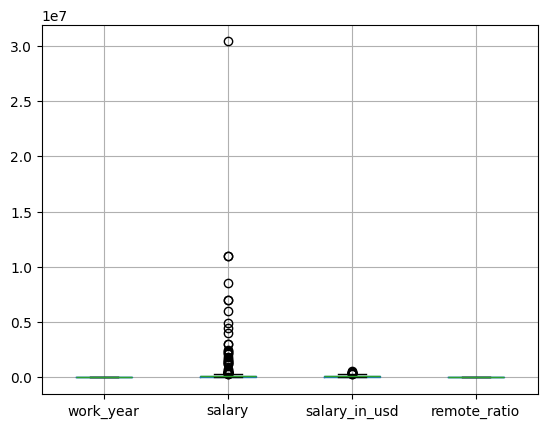

In [ ]:
df[num_cols].boxplot()

I think there is one outlier in salary column, lets see

In [ ]:
df[df["salary"] > 10000000]["salary"].to_frame().T.style.set_properties(**table_style)

,7,102,177
salary,11000000,11000000,30400000


There is a one anomaly "30400000" at index 177 because the averagge data is at 11000000 we mus drop!

In [ ]:
df["salary"] = df["salary"].drop(index=[177])

# Lets see again
df[df["salary"] > 10000000]["salary"].to_frame().T.style.set_properties(**table_style)

,7,102
salary,11000000.000000,11000000.000000


__Check anomalies values in categorical values__

In [ ]:
for col in cat_cols:
  print(f"{col}: {df[col].unique()}")

experience_level: ['MI' 'SE' 'EN' 'EX']
employment_type: ['FT' 'CT' 'PT' 'FL']
job_title: ['Data Scientist' 'Machine Learning Scientist' 'Big Data Engineer'
 'Product Data Analyst' 'Machine Learning Engineer' 'Data Analyst'
 'Lead Data Scientist' 'Business Data Analyst' 'Lead Data Engineer'
 'Lead Data Analyst' 'Data Engineer' 'Data Science Consultant'
 'BI Data Analyst' 'Director of Data Science' 'Research Scientist'
 'Machine Learning Manager' 'Data Engineering Manager'
 'Machine Learning Infrastructure Engineer' 'ML Engineer' 'AI Scientist'
 'Computer Vision Engineer' 'Principal Data Scientist'
 'Data Science Manager' 'Head of Data' '3D Computer Vision Researcher'
 'Data Analytics Engineer' 'Applied Data Scientist'
 'Marketing Data Analyst' 'Cloud Data Engineer' 'Financial Data Analyst'
 'Computer Vision Software Engineer' 'Director of Data Engineering'
 'Data Science Engineer' 'Principal Data Engineer'
 'Machine Learning Developer' 'Applied Machine Learning Scientist'
 'Data Analyt

There is so many unique values in categorical columns!<br>
We can't make it to manual like 0,1,2,3 so we need label encoder to make it number

### Labeling categorical columns

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in cat_cols:
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col])
  label_encoders[col] = le

# See the results
df[cat_cols].head().style.set_properties(**table_style)

,experience_level,employment_type,job_title,salary_currency,employee_residence,company_location,company_size
0,2,2,22,7,14,12,0
1,3,2,41,16,32,29,2
2,3,2,7,8,20,18,1
3,2,2,47,16,23,20,2
4,3,2,38,16,55,48,0


### See the correlation of datasets

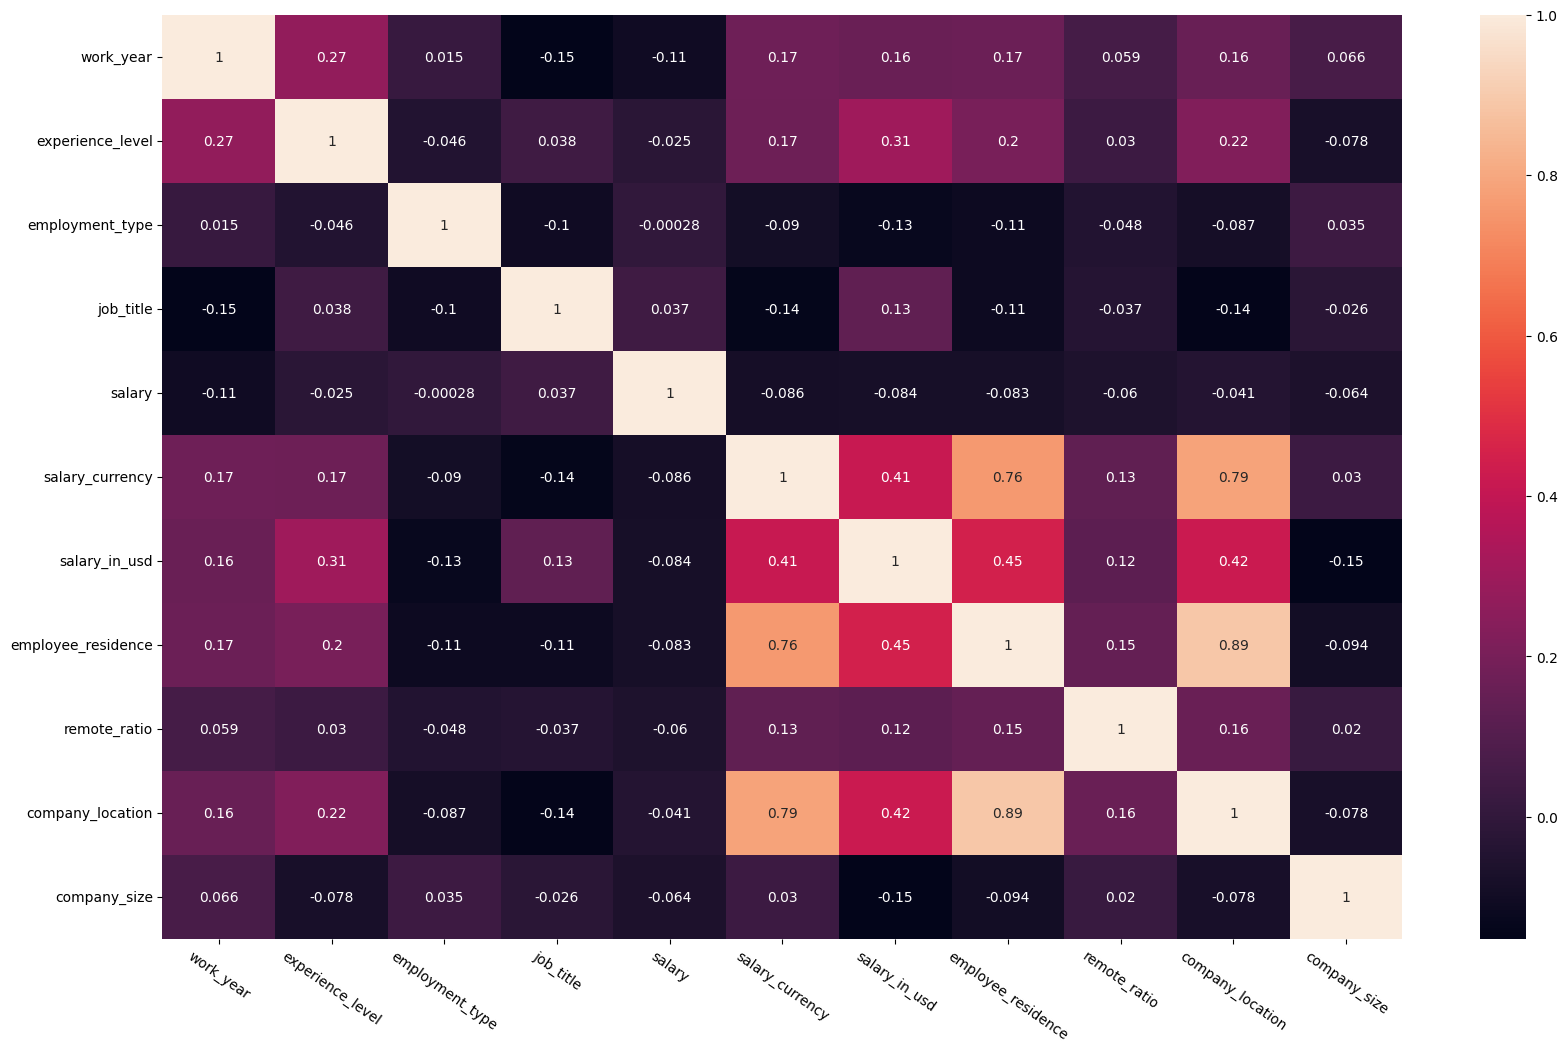

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 12))
sns.heatmap(df.corr(), annot=True, linecolor="black")
plt.xticks(rotation=-35)
plt.show()

THe mos suitable for our target (salary_in_usd) is "company_location", "employe_residence", "salary_currency", "experience_level"<br>
There is three colums may can suitable: "remote_ratio", "job_title", "work_year", "employment_type", "company_size"

__Lets see preview the final data__

In [ ]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,2,2,22,70000.0,7,79833,14,0,12,0
1,2020,3,2,41,260000.0,16,260000,32,0,29,2
2,2020,3,2,7,85000.0,8,109024,20,50,18,1
3,2020,2,2,47,20000.0,16,20000,23,0,20,2
4,2020,3,2,38,150000.0,16,150000,55,50,48,0


### Splitting data to training and testing

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["salary_in_usd", "salary_currency", "salary"])
y = df.salary_in_usd

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Scaler with Standart Scaler
I just try to make Standart Scaler may model give good accuracy

In [ ]:
from sklearn.preprocessing import StandardScaler

standart_scaler = StandardScaler()

X_train_scale = standart_scaler.fit_transform(X_train)
X_test_scale = standart_scaler.transform(X_test)

### Modeling<br>
I choose RandomForestRegressor because this model suitable for small datasets and regressor/forecast. <br>
I use GridSearchCV to search best params

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

model_test = RandomForestRegressor()

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

grid_seach = GridSearchCV(model_test, params, cv=5, n_jobs=-1, scoring="neg_mean_squared_error")
grid_seach.fit(X_train_scale, y_train)

print(f"Best parmas: {grid_seach.best_params_}")
print(f"Score MSE: {abs(grid_seach.best_score_)}")

Best parmas: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Score MSE: 2884334541.0861807


We got the best params is : <br>
now lets use

In [ ]:
model = RandomForestRegressor(max_depth=None, min_samples_split=2, n_estimators=100)
model.fit(X_train_scale, y_train)

y_pred = model.predict(X_test_scale)

### Evaluate with
+ MSE
+ MAE
+ RMSE
+ R2 Score

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, r2_score

mae_score = mean_absolute_error(y_test, y_pred)
mse_score = mean_squared_error(y_test, y_pred)
rmse_score = root_mean_squared_error(y_test, y_pred)
r2_score = r2_score(y_test, y_pred)

print(f"MAE Score: {mae_score}")
print(f"MSE Score: {mse_score}")
print(f"RMSE Score: {rmse_score}")
print(f"R2 Score: {r2_score}")

MAE Score: 34738.07913816903
MSE Score: 3267206359.2814145
RMSE Score: 57159.48179682365
R2 Score: 0.31987949822396966


__MAE__<br>

MAE = $\frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$

Predict = 4, 3, 7<br>
Actual  = 2, 4, 3<br>
MAE = (2 + 1 + 4) / 3<br>
MAE = 2.33

Maka jarak selisih prediksi adalah antara 2.33<br>
Contoh nilai aktual adalah 10 maka kemungkinan hasil prediksi di rentan 7.67 dan 12.33

__MSE__<br>

MSE = $\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$

Predict = 4, 3, 7<br>
Actual  = 2, 4, 3<br>
MSE = 4 + 1 + 16 / 3<br>
MSE = 7

MSE memperhitungkan seberapa sering dan seberapa jauh model meleset dalam prediksi.

__RMSE__<br>
RMSE = $\sqrt{MSE}$<br>
Mengembalikan nilai MSE ke skala yang sebenarnya.<br>
RMSE dapat diinterpretasikan sebagai "kesalahan rata-rata yang diharapkan" dalam satuan yang sama dengan data aslinya.

__R$^2$ Score__<br>
$R^2$ = $1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y_i})^2}{\sum_{i=1}^{n}(y_i - \bar{y_i})^2}$

Predict = 4, 7, 3
Actual = 2, 5, 4

$SS_\text{residual}$:<br>
(4 - 2)$^2$ + (7 - 5)$^2$ + (3 - 4)$^2$<br>
4 + 4 + 1 = 9<br><br>
$\bar{y} = \frac{2 + 5 + 4}{3} = 3.62$<br><br>
$SS_\text{total}$:<br>
(4 - 3.62)$^2$ + (5 - 3.62)$^2$ + (4 - 3.62)$^2$<br>
2.79 + 1.78 + 0.11 = 4.68

$\frac{9}{4.68} = 1.92$<br>
$R^2 = 1 - 1.92$<br>
$R^2 = -0.92$

R² Score mengukur seberapa baik model regresi menjelaskan variabilitas dalam data<br>
Misal jika saya memasukan hanya 5 feature dalam training akan menghasilkan -0.92, lalu jika saya menambahkan 1 atau 2 feature yang memiliki pengaruh dalam prediksi target (bisa di lihat dari corelasi) mungkin scorenya akan lebih baik.